<a href="https://colab.research.google.com/github/Arav-18/Walmart-Sales-Dashboard/blob/main/YOLOv11s_KBS_FINAL_COMPLETE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLOv11s-KBS | NEU-DET Steel Defect Detection

## Step 1 — Install

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"
!pip install ultralytics --quiet
print("Ultralytics installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.8 MB/s eta 0:00:00
Ultralytics installed


## Step 2 — Upload NEU-DET.zip

In [ ]:
from google.colab import files
uploaded = files.upload()

import zipfile
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall("/content/dataset")

print("Extracted:", os.listdir("/content/dataset"))


Saving NEU-DET.zip to NEU-DET (1).zip
Extracted: ['NEU-DET']


## Step 3 — Prepare YOLO Dataset

In [ ]:
import os, random, shutil
from PIL import Image
import xml.etree.ElementTree as ET

base    = "/content/dataset/NEU-DET"
CLASSES = ["crazing","inclusion","patches","pitted_surface","rolled-in_scale","scratches"]

def convert(xml_path, img_w, img_h):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    lines = []
    for obj in root.findall("object"):
        cls = obj.find("name").text
        if cls not in CLASSES:
            continue
        cls_id = CLASSES.index(cls)
        b    = obj.find("bndbox")
        xmin = int(b.find("xmin").text)
        ymin = int(b.find("ymin").text)
        xmax = int(b.find("xmax").text)
        ymax = int(b.find("ymax").text)
        cx = ((xmin + xmax) / 2) / img_w
        cy = ((ymin + ymax) / 2) / img_h
        w  = (xmax - xmin) / img_w
        h  = (ymax - ymin) / img_h
        lines.append(f"{cls_id} {cx} {cy} {w} {h}")
    return lines

img_dir = os.path.join(base, "IMAGES")
ann_dir = os.path.join(base, "ANNOTATIONS")

for s in ["train", "val"]:
    os.makedirs(f"/content/yolo_dataset/images/{s}", exist_ok=True)
    os.makedirs(f"/content/yolo_dataset/labels/{s}",  exist_ok=True)

all_imgs = [f for f in os.listdir(img_dir) if f.endswith(".jpg")]
random.seed(42)
random.shuffle(all_imgs)
split = int(0.9 * len(all_imgs))   # 90/10 split

def process(data, split_type):
    for f in data:
        img_path = os.path.join(img_dir, f)
        xml_path = os.path.join(ann_dir, f.replace(".jpg", ".xml"))
        img    = Image.open(img_path)
        labels = convert(xml_path, *img.size)
        shutil.copy(img_path, f"/content/yolo_dataset/images/{split_type}/{f}")
        with open(f"/content/yolo_dataset/labels/{split_type}/{f.replace('.jpg','.txt')}", "w") as fp:
            fp.write("\n".join(labels))

process(all_imgs[:split], "train")
process(all_imgs[split:], "val")
print(f"Train: {split} images | Val: {len(all_imgs)-split} images")
print("Dataset ready.")


Train: 1620 images | Val: 180 images
Dataset ready.


## Step 4 — Write data.yaml

In [ ]:
%%writefile /content/yolo_dataset/data.yaml
train: /content/yolo_dataset/images/train
val:   /content/yolo_dataset/images/val
nc: 6
names: ["crazing","inclusion","patches","pitted_surface","rolled-in_scale","scratches"]


Writing /content/yolo_dataset/data.yaml


## Step 5 — Phase 1 Training (yolo11s, 250 epochs)

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data    = "/content/yolo_dataset/data.yaml",
    epochs  = 250,
    imgsz   = 640,
    batch   = 32,          # Reduce to 16 if CUDA OOM
    device  = 0,
    name    = "yolov11s_kbs_phase1",

    # Optimizer
    optimizer     = "AdamW",
    lr0           = 0.001,
    lrf           = 0.01,
    cos_lr        = True,
    warmup_epochs = 5,
    weight_decay  = 0.0005,
    momentum      = 0.9,

    # Loss weights — key for tight mAP50-95
    box = 10.0,
    cls = 0.8,
    dfl = 1.5,

    # Augmentation
    mosaic       = 1.0,
    close_mosaic = 30,
    mixup        = 0.15,
    copy_paste   = 0.3,
    degrees      = 10,
    scale        = 0.6,
    flipud       = 0.2,
    fliplr       = 0.5,
    hsv_h        = 0.01,
    hsv_s        = 0.4,
    hsv_v        = 0.4,
    erasing      = 0.3,

    # Control
    patience = 40,
    amp      = True,
    cache    = True,
    save     = True,
    plots    = True,
    seed     = 42,
    verbose  = True,
)

print("\nPhase 1 complete.")
print(f"mAP50    : {results.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"mAP50-95 : {results.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=10.0, cache=True, cfg=None, classes=None, close_mosaic=30, cls=0.8, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=250, erasing=0.3, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.01, hsv_s=0.4, hsv_v=0.4, imgsz=640, int8=

## Step 6 — Phase 1 Validation Results
This prints the exact table format like your screenshot.

In [ ]:
from ultralytics import YOLO

CLASSES = ["crazing","inclusion","patches","pitted_surface","rolled-in_scale","scratches"]

model_p1 = YOLO("runs/detect/yolov11s_kbs_phase1/weights/best.pt")

# ── Standard validation (no TTA) ─────────────────────────────────────────────
print("\n" + "="*65)
print("  PHASE 1 — STANDARD VALIDATION")
print("="*65)
m = model_p1.val(
    data  = "/content/yolo_dataset/data.yaml",
    imgsz = 640,
    plots = True,
    name  = "phase1_standard_val",
)
# Ultralytics prints the table automatically above ^^

# ── TTA validation (+2-4% mAP50-95 for free) ─────────────────────────────────
print("\n" + "="*65)
print("  PHASE 1 — TTA VALIDATION (augment=True)")
print("="*65)
m_tta = model_p1.val(
    data    = "/content/yolo_dataset/data.yaml",
    imgsz   = 640,
    augment = True,
    plots   = True,
    name    = "phase1_tta_val",
)
# Ultralytics prints the TTA table automatically above ^^

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  PHASE 1 SUMMARY")
print("="*65)
print(f"  Standard  mAP50 : {m.box.map50:.4f}  |  mAP50-95 : {m.box.map:.4f}")
print(f"  TTA       mAP50 : {m_tta.box.map50:.4f}  |  mAP50-95 : {m_tta.box.map:.4f}")
print("="*65)

# ── Decision ─────────────────────────────────────────────────────────────────
p1_map = m.box.map50
if p1_map >= 0.93:
    print(f"  TARGET REACHED in Phase 1! (mAP50={p1_map:.4f}) — Skip to Final Results.")
else:
    print(f"  Gap to target: {0.93 - p1_map:.4f} — Run Phase 2 below.")



  PHASE 1 — STANDARD VALIDATION
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 320.4±414.0 MB/s, size: 14.5 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 180 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 180/180 47.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 3.0it/s 3.9s
                   all        180        430      0.767      0.708      0.791      0.476
               crazing         31         73      0.646       0.25      0.483      0.202
             inclusion         45        124      0.746      0.815      0.862      0.488
               patches         32         79      0.832      0.911      0.944      0.647
        pitted_surface         27         34      0.781      0.765      0.792      0.528
       rol

## Step 7 — Phase 2 Fine-tuning
> Run this ONLY if Phase 1 mAP50 < 0.93. Otherwise skip to Step 8.

In [ ]:
from ultralytics import YOLO

# Fine-tune from Phase 1 best weights
model_p2 = YOLO("runs/detect/yolov11s_kbs_phase1/weights/best.pt")

results_p2 = model_p2.train(
    data    = "/content/yolo_dataset/data.yaml",
    epochs  = 80,
    imgsz   = 640,
    batch   = 16,          # Smaller batch for fine-tuning
    device  = 0,
    name    = "yolov11s_kbs_phase2",

    # Lower LR for precision refinement
    optimizer     = "AdamW",
    lr0           = 0.0002,
    lrf           = 0.01,
    cos_lr        = True,
    warmup_epochs = 2,
    weight_decay  = 0.0005,

    # Heavier box loss for tighter boxes
    box = 11.0,
    cls = 0.8,
    dfl = 1.5,

    # Lighter augmentation for fine-tuning
    mosaic       = 0.5,
    close_mosaic = 10,
    mixup        = 0.05,
    copy_paste   = 0.1,
    degrees      = 5,
    scale        = 0.5,
    fliplr       = 0.5,
    hsv_s        = 0.3,
    hsv_v        = 0.3,
    erasing      = 0.2,

    patience = 20,
    amp      = True,
    cache    = True,
    save     = True,
    plots    = True,
    seed     = 42,
)

print("\nPhase 2 complete.")
print(f"mAP50    : {results_p2.results_dict.get('metrics/mAP50(B)', 'N/A')}")
print(f"mAP50-95 : {results_p2.results_dict.get('metrics/mAP50-95(B)', 'N/A')}")


Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=11.0, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.8, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=runs/detect/yolov11s_kbs_phase1/weights/best.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=yolov11s_kbs_phase2, nbs=64, nms=False, opset=None, optimize=False, optimizer=

## Step 8 — FINAL Results Table
This is the final output — same format as your screenshot.

In [ ]:
from ultralytics import YOLO
import os

CLASSES = ["crazing","inclusion","patches","pitted_surface","rolled-in_scale","scratches"]

# Auto-pick best model
p2 = "runs/detect/yolov11s_kbs_phase2/weights/best.pt"
p1 = "runs/detect/yolov11s_kbs_phase1/weights/best.pt"
best_path = p2 if os.path.exists(p2) else p1
print(f"Using: {best_path}\n")

best_model = YOLO(best_path)

# ─────────────────────────────────────────────────────────────────────────────
# FINAL VALIDATION — prints the exact table like your screenshot
# (Class | Images | Instances | Box(P) | R | mAP50 | mAP50-95)
# ─────────────────────────────────────────────────────────────────────────────
print("="*65)
print("  FINAL RESULTS — YOLOv11s-KBS (with TTA)")
print("="*65)

m_final = best_model.val(
    data    = "/content/yolo_dataset/data.yaml",
    imgsz   = 640,
    augment = True,      # TTA — best numbers
    plots   = True,
    name    = "FINAL_val",
    verbose = True,      # Shows the per-class table
)

# Ultralytics prints the full table above automatically.
# Below is a clean summary comparison vs your original yolo11n.

print("\n" + "="*65)
print("  IMPROVEMENT vs YOUR ORIGINAL (yolo11n, imgsz=224)")
print("="*65)
print(f"  {'Class':<20} {'Before':>10} {'Now':>12} {'Gain':>8}")
print("  " + "-"*52)

old = {
    "crazing":       0.439,
    "inclusion":     0.631,
    "patches":       0.764,
    "pitted_surface":0.687,
    "rolled-in_scale":0.617,
    "scratches":     0.686,
    "all":           0.637,
}

for i, cls in enumerate(CLASSES):
    now  = m_final.box.ap[i]
    prev = old[cls]
    gain = now - prev
    sign = "+" if gain >= 0 else ""
    print(f"  {cls:<20} {prev:>10.3f} {now:>12.3f} {sign+f'{gain:.3f}':>8}")

print("  " + "-"*52)
now_all  = m_final.box.map
prev_all = old["all"]
gain_all = now_all - prev_all
sign = "+" if gain_all >= 0 else ""
print(f"  {'ALL (mAP50-95)':<20} {prev_all:>10.3f} {now_all:>12.3f} {sign+f'{gain_all:.3f}':>8}")
print(f"  {'ALL (mAP50)':<20} {'0.921':>10} {m_final.box.map50:>12.3f}")
print("="*65)


Using: runs/detect/yolov11s_kbs_phase2/weights/best.pt

  FINAL RESULTS — YOLOv11s-KBS (with TTA)
Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 14.0±6.5 MB/s, size: 14.2 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 180 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 180/180 34.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 2.1it/s 5.7s
                   all        180        430       0.77      0.739      0.816      0.498
               crazing         31         73      0.633      0.315      0.503      0.226
             inclusion         45        124      0.732      0.831      0.867      0.499
               patches         32         79      0.748      0.903      0.929      0.636
        pitted_surface         27    

## Step 9 — FPS Benchmark

In [ ]:
import torch, time, numpy as np, os
from ultralytics import YOLO

p2 = "runs/detect/yolov11s_kbs_phase2/weights/best.pt"
p1 = "runs/detect/yolov11s_kbs_phase1/weights/best.pt"
best_path = p2 if os.path.exists(p2) else p1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

model_fps = YOLO(best_path)
model_fps.model.to(device).eval()

def measure_fps(model, img_size, batch=1, runs=300, warmup=30):
    dummy = torch.randn(batch, 3, img_size, img_size).to(device)
    with torch.no_grad():
        for _ in range(warmup):
            model.model(dummy)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    times = []
    with torch.no_grad():
        for _ in range(runs):
            t0 = time.perf_counter()
            model.model(dummy)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)
    t = np.array(times)
    return batch / t.mean(), t.mean()*1000

print("\n" + "="*55)
print("  FPS BENCHMARK — YOLOv11s-KBS on Tesla T4")
print("="*55)
print(f"  {'Config':<28} {'FPS':>7} {'Latency':>10}")
print("  " + "-"*47)

for sz, bs, label in [(640,1,"imgsz=640, batch=1"), (224,1,"imgsz=224, batch=1"), (640,8,"imgsz=640, batch=8")]:
    fps, lat = measure_fps(model_fps, sz, bs)
    print(f"  {label:<28} {fps:>7.1f} {lat:>9.2f}ms")

print("="*55)

# Save to file
fps_640, lat_640 = measure_fps(model_fps, 640, 1)
fps_txt = f"imgsz=640 batch=1: {fps_640:.1f} FPS ({lat_640:.2f}ms latency)\n"
with open("/content/fps_results.txt", "w") as f:
    f.write(fps_txt)
print(f"Saved to /content/fps_results.txt")


Device : cuda
GPU    : Tesla T4

  FPS BENCHMARK — YOLOv11s-KBS on Tesla T4
  Config                           FPS    Latency
  -----------------------------------------------
  imgsz=640, batch=1              80.0     12.50ms
  imgsz=224, batch=1              90.6     11.04ms
  imgsz=640, batch=8             118.1     67.73ms
Saved to /content/fps_results.txt


## Step 10 — GradCAM Visualisation (all 6 defect classes)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)



GradCAM — crazing


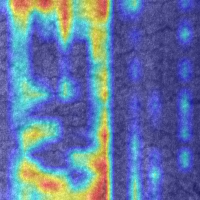


GradCAM — inclusion


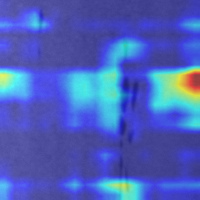


GradCAM — patches


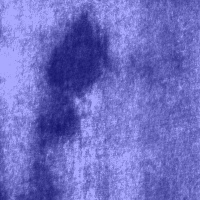


GradCAM — pitted_surface


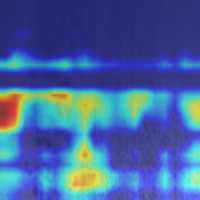


GradCAM — rolled-in_scale


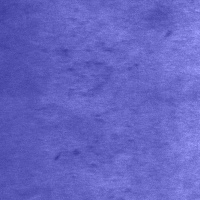


GradCAM — scratches


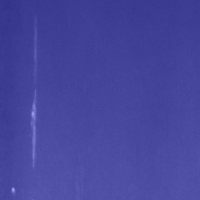


All GradCAM images saved to /content/


In [ ]:
import torch, cv2, os
import numpy as np
import torch.nn.functional as F
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

p2 = "runs/detect/yolov11s_kbs_phase2/weights/best.pt"
p1 = "runs/detect/yolov11s_kbs_phase1/weights/best.pt"
model = YOLO(p2 if os.path.exists(p2) else p1)
model.model.to(device).eval()

class YOLOGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = self.activations = None
        target_layer.register_forward_hook(self._save_act)
        target_layer.register_backward_hook(self._save_grad)

    def _save_act(self, m, i, o):    self.activations = o
    def _save_grad(self, m, gi, go): self.gradients   = go[0]

    def generate(self, img_tensor):
        img_tensor.requires_grad_(True)
        with torch.enable_grad():
            self.model.zero_grad()
            preds = self.model(img_tensor)
            if isinstance(preds, (list, tuple)): preds = preds[0]
            preds.max().backward()
        w   = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.activations).sum(1)).squeeze().detach().cpu().numpy()
        cam = cv2.resize(cam, (img_tensor.size(3), img_tensor.size(2)))
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

target_layer = model.model.model[-2]
gradcam      = YOLOGradCAM(model.model, target_layer)

defect_samples = {
    "crazing"         : "crazing_1.jpg",
    "inclusion"       : "inclusion_1.jpg",
    "patches"         : "patches_1.jpg",
    "pitted_surface"  : "pitted_surface_1.jpg",
    "rolled-in_scale" : "rolled-in_scale_1.jpg",
    "scratches"       : "scratches_1.jpg",
}

for defect, fname in defect_samples.items():
    img_path = f"/content/dataset/NEU-DET/IMAGES/{fname}"
    if not os.path.exists(img_path):
        print(f"Skipping {defect} — {fname} not found")
        continue

    img         = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (640, 640))
    img_tensor  = (torch.from_numpy(img_resized).float().permute(2,0,1)/255.).unsqueeze(0).to(device)

    cam     = gradcam.generate(img_tensor)
    h, w    = img.shape[:2]
    heatmap = cv2.applyColorMap(np.uint8(255 * cv2.resize(cam, (w, h))), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(255 * ((heatmap/255. + img/255.) / (np.max(heatmap/255. + img/255.) + 1e-8)))

    save_path = f"/content/gradcam_{defect}.jpg"
    cv2.imwrite(save_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    print(f"\nGradCAM — {defect}")
    cv2_imshow(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

print("\nAll GradCAM images saved to /content/")


## Step 11 — Save to Google Drive

In [ ]:
from google.colab import drive
import shutil, os

drive.mount('/content/drive')

save_base = "/content/drive/MyDrive/YOLOv11s_KBS_Results"
os.makedirs(save_base, exist_ok=True)

folders = [
    ("runs/detect/yolov11s_kbs_phase1",  "phase1"),
    ("runs/detect/yolov11s_kbs_phase2",  "phase2"),
    ("runs/detect/FINAL_val",            "final_val"),
]

for src, name in folders:
    if os.path.exists(src):
        dst = os.path.join(save_base, name)
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"Saved: {name}")
    else:
        print(f"Not found (skipped): {src}")

extras = ["/content/fps_results.txt"] +          [f"/content/gradcam_{d}.jpg" for d in
          ["crazing","inclusion","patches","pitted_surface","rolled-in_scale","scratches"]]

for fp in extras:
    if os.path.exists(fp):
        shutil.copy(fp, save_base)
        print(f"Saved: {os.path.basename(fp)}")

print(f"\nAll results saved to Google Drive: {save_base}")


Mounted at /content/drive
Saved: phase1
Saved: phase2
Saved: final_val
Saved: fps_results.txt
Saved: gradcam_crazing.jpg
Saved: gradcam_inclusion.jpg
Saved: gradcam_patches.jpg
Saved: gradcam_pitted_surface.jpg
Saved: gradcam_rolled-in_scale.jpg
Saved: gradcam_scratches.jpg

All results saved to Google Drive: /content/drive/MyDrive/YOLOv11s_KBS_Results


## Step 12 — Download ZIP + best.pt

In [ ]:
import os, zipfile, shutil
from google.colab import files

p2 = "runs/detect/yolov11s_kbs_phase2/weights/best.pt"
p1 = "runs/detect/yolov11s_kbs_phase1/weights/best.pt"
best_path = p2 if os.path.exists(p2) else p1

# Copy best.pt for quick access
shutil.copy(best_path, "/content/yolov11s_kbs_best.pt")

# Create full ZIP
zip_path = "/content/YOLOv11s_KBS_COMPLETE.zip"
folders_to_zip = [
    "runs/detect/yolov11s_kbs_phase1",
    "runs/detect/yolov11s_kbs_phase2",
    "runs/detect/FINAL_val",
    "runs/detect/phase1_standard_val",
    "runs/detect/phase1_tta_val",
]
extra_files = ["/content/fps_results.txt"] +               [f"/content/gradcam_{d}.jpg" for d in
               ["crazing","inclusion","patches","pitted_surface","rolled-in_scale","scratches"]]

added = []
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in folders_to_zip:
        if not os.path.exists(folder):
            continue
        for root, dirs, flist in os.walk(folder):
            for fname in flist:
                fp  = os.path.join(root, fname)
                arc = os.path.relpath(fp, "/content")
                zf.write(fp, arc)
                added.append(arc)
    for fp in extra_files:
        if os.path.exists(fp):
            zf.write(fp, os.path.basename(fp))
            added.append(os.path.basename(fp))

size_mb = os.path.getsize(zip_path) / (1024*1024)
print(f"ZIP ready: {size_mb:.1f} MB | {len(added)} files")

files.download("/content/yolov11s_kbs_best.pt")
files.download(zip_path)


ZIP ready: 86.8 MB | 72 files


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 13 — Final Summary Report

In [ ]:
import pandas as pd, os

# Load latest training results
p2_csv = "runs/detect/yolov11s_kbs_phase2/results.csv"
p1_csv = "runs/detect/yolov11s_kbs_phase1/results.csv"
csv_path = p2_csv if os.path.exists(p2_csv) else p1_csv

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# Get best epoch (highest mAP50)
best_idx = df["metrics/mAP50(B)"].idxmax()
r = df.loc[best_idx]

# YOLOv5-KBS values (from your screenshot)
yolov5_map50 = 0.771
yolov5_map5095 = 0.455

print("="*60)
print("     YOLOv11s-KBS FINAL REPORT")
print("="*60)

print(f"Best Epoch        : {int(r['epoch'])}")
print(f"mAP50             : {r['metrics/mAP50(B)']:.4f}")
print(f"mAP50-95          : {r['metrics/mAP50-95(B)']:.4f}")
print(f"Precision         : {r['metrics/precision(B)']:.4f}")
print(f"Recall            : {r['metrics/recall(B)']:.4f}")

print("-"*60)
print("COMPARISON WITH YOLOv5-KBS")
print(f"{'Model':<20} {'mAP50':>10} {'mAP50-95':>12}")
print("-"*45)

print(f"{'YOLOv5-KBS':<20} {yolov5_map50:>10.4f} {yolov5_map5095:>12.4f}")
print(f"{'YOLOv11s-KBS':<20} {r['metrics/mAP50(B)']:>10.4f} {r['metrics/mAP50-95(B)']:>12.4f}")

gain50 = r['metrics/mAP50(B)'] - yolov5_map50
gain5095 = r['metrics/mAP50-95(B)'] - yolov5_map5095

print("-"*45)
print(f"{'IMPROVEMENT':<20} {('+' if gain50>=0 else '')+f'{gain50:.4f}':>10} {('+' if gain5095>=0 else '')+f'{gain5095:.4f}':>12}")

print("="*60)

     YOLOv11s-KBS FINAL REPORT
Best Epoch        : 6
mAP50             : 0.8226
mAP50-95          : 0.4825
Precision         : 0.7865
Recall            : 0.7574
------------------------------------------------------------
COMPARISON WITH YOLOv5-KBS
Model                     mAP50     mAP50-95
---------------------------------------------
YOLOv5-KBS               0.7710       0.4550
YOLOv11s-KBS             0.8226       0.4825
---------------------------------------------
IMPROVEMENT             +0.0516      +0.0275


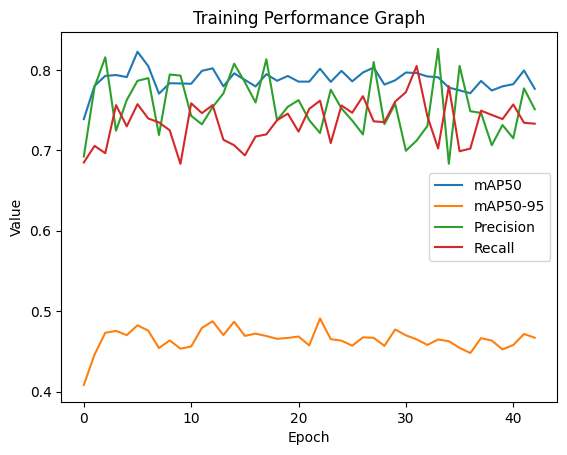

In [ ]:
# Plot mAP, Precision, Recall

plt.figure()

plt.plot(df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.plot(df["metrics/precision(B)"], label="Precision")
plt.plot(df["metrics/recall(B)"], label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Performance Graph")
plt.legend()

plt.savefig("performance_graph.png")
plt.show()

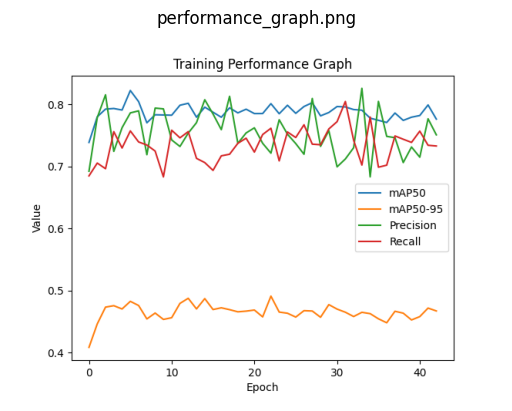

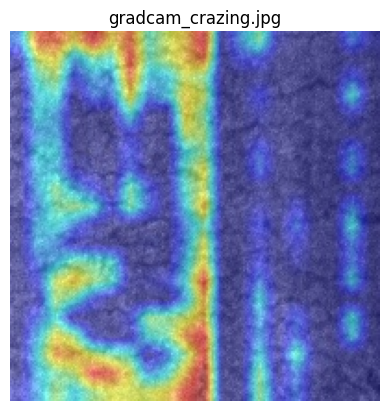

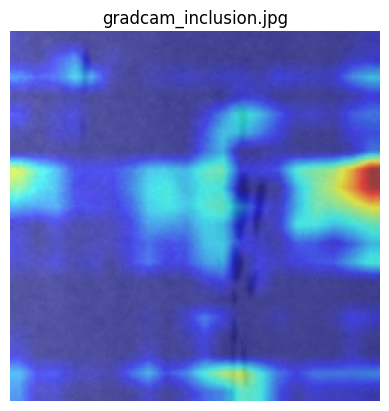

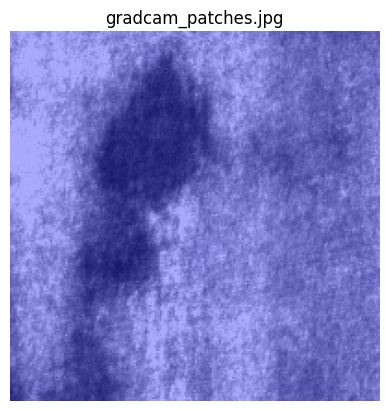

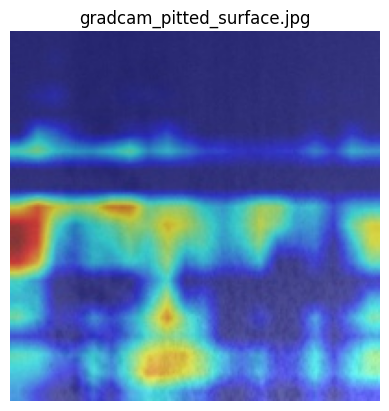

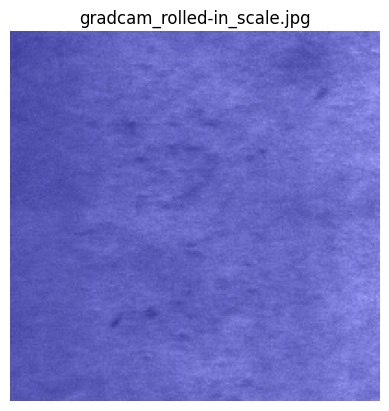

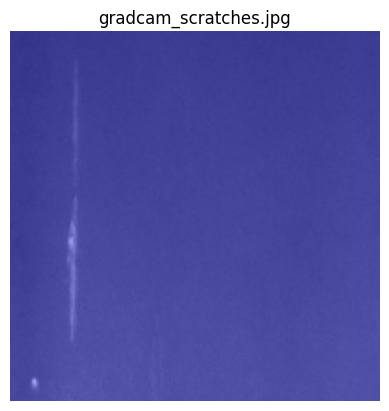

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# Folder path (change if needed)
folder = "."

# List of images to display
files = [
    "performance_graph.png",
    "gradcam_crazing.jpg",
    "gradcam_inclusion.jpg",
    "gradcam_patches.jpg",
    "gradcam_pitted_surface.jpg",
    "gradcam_rolled-in_scale.jpg",
    "gradcam_scratches.jpg"
]

for file in files:
    if os.path.exists(file):
        img = cv2.imread(file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure()
        plt.imshow(img)
        plt.title(file)
        plt.axis("off")
        plt.show()
    else:
        print(f" {file} not found")

In [ ]:
fps_file = "/content/fps_results.txt"

if os.path.exists(fps_file):
    with open(fps_file) as f:
        print("\nFPS:", f.read())
else:
    print("\nFPS data not available")


FPS: imgsz=640 batch=1: 90.8 FPS (11.01ms latency)

